# Activity 3: Mapping Fine-Grained Migration Flows

In this notebook, you will map some of our migration data.

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

We probably will not have time to go over both case studies in the workshop---feel free to skip #2 and go ahead to #3 if you are more interested in wildfires.

Keep this link open, it could be helpful if you are not familiar with Geopandas: https://geopandas.org/en/stable/docs/user_guide/mapping.html

You should add the csv you received with MIGRATE data to the `data` directory. Note that the file contains only flows from 2018 to 2019, departing either California or New York CBGs.

In [7]:
MIGRATE_data = pd.read_csv('../data/MIGRATE_sample_2018-2019.csv')

## 1. Collecting Census spatial data

There are several ways to collect Census spatial data. Here we will use [pygris](https://walker-data.com/pygris/). It needs to be installed via pip, so run the following cell:

In [8]:
! pip install pygris

You should be able to now import pygris and use the `block_groups()` function to collect all CBGs in a given state. This will take ~1 minute. You may see some errors of HTTP download---the Census website is in flux these days, sadly, and pygris is trying to look for alternatives to download the data

In [9]:
import pygris
NY_CBGs = pygris.block_groups(state='36', year=2010) #New York state
CA_CBGs = pygris.block_groups(state='06', year=2010) #California

HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...


This is how one such dataframe looks like:

In [10]:
NY_CBGs.head()

,STATEFP10,COUNTYFP10,TRACTCE10,BLKGRPCE10,GEOID10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,36,007,012101,1,360070121011,Block Group 1,G5030,S,17263315,38069,+42.2174896,-075.8790269,"POLYGON ((-75.89054 42.18697, -75.8992 42.1781..."
1,36,007,012101,4,360070121014,Block Group 4,G5030,S,5586521,104976,+42.1831807,-075.8760650,"POLYGON ((-75.87509 42.17416, -75.8754 42.1741..."
2,36,007,012101,3,360070121013,Block Group 3,G5030,S,1845677,0,+42.1931188,-075.8462160,"POLYGON ((-75.83838 42.1974, -75.83813 42.1974..."
3,36,007,012102,4,360070121024,Block Group 4,G5030,S,5082696,183811,+42.1823571,-075.8436840,"POLYGON ((-75.85079 42.16052, -75.85114 42.160..."
4,36,007,012102,3,360070121023,Block Group 3,G5030,S,1094202,145781,+42.1677108,-075.8793775,"POLYGON ((-75.87457 42.17416, -75.87338 42.174..."


## 2. Mapping flows in New York City

We will start mapping flows in New York City, showing one advantage of fine-grained migration data: it reveals urban, neighborhood-level dynamics.

First, we select the CBGs in New York City --- that is, CBGs in one of the 5 NYC counties: Manhattan, Queens, Bronx, Brooklyn, and Staten Island


In [11]:
NYC_counties = {'Bronx': '005', 'Brooklyn':'047', 'Manhattan':'061', 'Queens':'081', 'Staten Island':'085'}
NYC_CBGs = NY_CBGs[NY_CBGs['COUNTYFP10'].isin(NYC_counties.values())].reset_index(drop=True)

To practice a simple plot:

<Axes: >

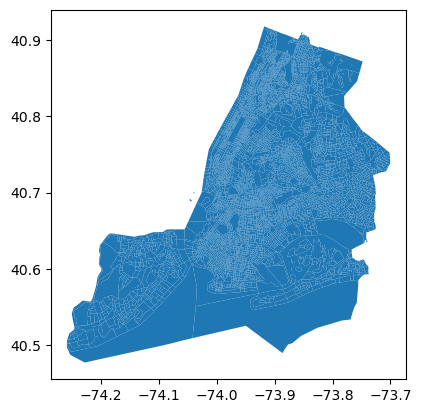

In [12]:
NYC_CBGs.plot() #Just call plot on a geodataframe!

You can treat geodataframe plots as any other matplotlib element. For example you could pass an ax or a figsize. See additional parameters:

In [13]:
NYC_CBGs.plot?

Signature:      NYC_CBGs.plot(*args, **kwargs)
Type:           GeoplotAccessor
String form:    <geopandas.plotting.GeoplotAccessor object at 0x174602cf0>
File:           ~/opt/anaconda3/envs/neatnet-debug/lib/python3.13/site-packages/geopandas/plotting.py
Docstring:     
Plot a GeoDataFrame.

Generate a plot of a GeoDataFrame with matplotlib.  If a
column is specified, the plot coloring will be based on values
in that column.

Parameters
----------
column : str, np.array, pd.Series, pd.Index (default None)
    The name of the dataframe column, np.array, pd.Series, or pd.Index
    to be plotted. If np.array, pd.Series, or pd.Index are used then it
    must have same length as dataframe. Values are used to color the plot.
    Ignored if `color` is also set.
kind: str
    The kind of plots to produce. The default is to create a map ("geo").
    Other supported kinds of plots from pandas:

    - 'line' : line plot
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hi

Note that the water is part of the CBGs---this is not desired sometimes. We could solve the issue by downloading the boundary of NYC and cropping all CBGs (a spatial overlay, or clip---see the Geopandas docs!). We could also use `pygris`, which has an `erase_water` function!. Note that this function is a bit slow---it needs to download water data---and also it will change the index of the geodataframe! So be careful

HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...


/Users/gsagostini/opt/anaconda3/envs/neatnet-debug/lib/python3.13/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 52 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


<Axes: >

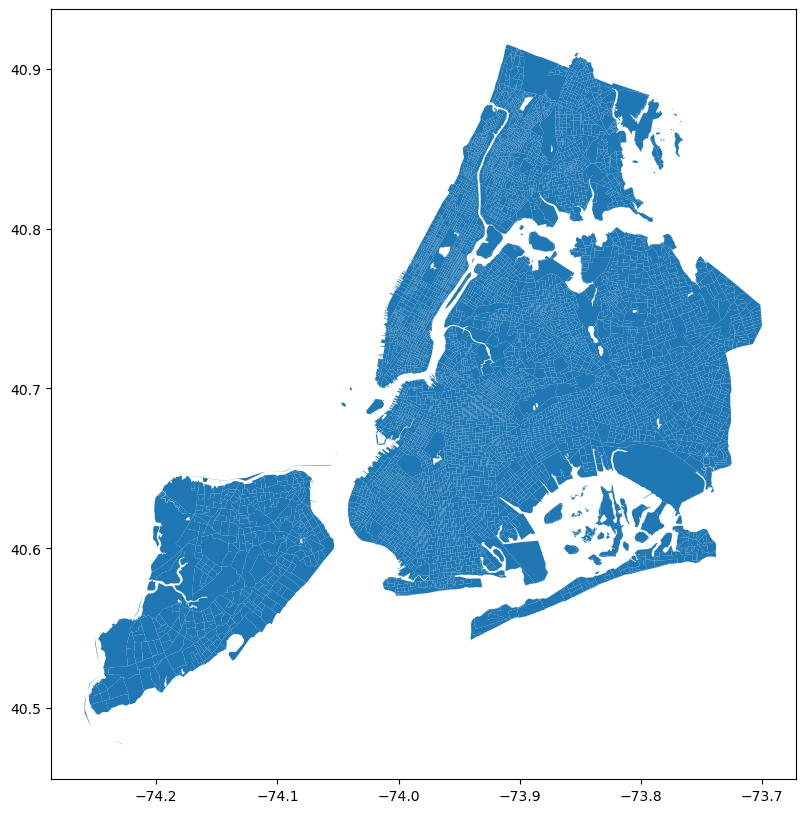

In [14]:
#This takes a while t run---40 seconds for me. It needs to download water data. Feel free to skip.
from pygris.utils import erase_water
NYC_CBGs_nowater = erase_water(NYC_CBGs)
NYC_CBGs_nowater.plot(figsize=(10,10))

### 1. Visualizing flows from Manhattan

Let's visualize flows from Manhattan, classified according to the destination. First, look at the MIGRATE dataframe. You will see that GEOIDs are given as integers---it is good practice to make sure they are strings (12 digits for CBGs).

In [15]:
MIGRATE_data['Origin'] = MIGRATE_data['Origin'].astype(str).str.zfill(12)
MIGRATE_data['Destination'] = MIGRATE_data['Destination'].astype(str).str.zfill(12)
MIGRATE_data.head()

,Origin,Destination,Flow
0,060014001001,010730129084,0.083755
1,060014001001,020200016011,2.956324
2,060014001001,040050002001,3.628941
3,060014001001,040130405191,2.678163
4,060014001001,040130610181,1.104190


We will then need to select the CBGs in Manhattan. To do that, note that GEOIDs are built geography by geography: they begin with the 2-digit state code (36 for NY), then the 3 digit county code (which... we have defined above for Manhattan---can you find it?).

In [16]:
start_of_a_Manhattan_GEOID = '36' + '061'
flows_out_of_Manhattan = MIGRATE_data.loc[MIGRATE_data['Origin'].str.startswith(start_of_a_Manhattan_GEOID)]

Now, we can use similar selections to find flows from Manhattan to different destinations. For the exercise, define NYC as the 5 counties above. That is someone moves outside of NYC if it doesnt move to Manhattan, Queens, Bronx, Brooklyn, or Staten Island.

In [17]:
#I will do the first one. We want flows from Manhattan to anywhere OUTSIDE New York state--i.e., destination GEOIDs that do NOT start with '36'.
flows_out_of_Manhattan_to_outside_NY = flows_out_of_Manhattan.loc[~flows_out_of_Manhattan['Destination'].str.startswith('36')].groupby('Origin')['Flow'].sum()

#We do the .groupby('Origin') because we want to sum all flows from each Manhattan CBGs to outside NY state.
# There are multiple destinations for each origin, so we need to group by origin and sum the flows. You could play around with mapping by destination too.
# In general, make sure to add this groupby statement after the following lines:

#Flows to NY state:
flows_out_of_Manhattan_to_NY = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith('36')].groupby('Origin')['Flow'].sum()

#Flows to NYC:
flows_out_of_Manhattan_to_NYC = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36061', '36081', '36085'))].groupby('Origin')['Flow'].sum()
#Hint: str.startswith allows you to supply a tuple of strings to test for i.e. .str.startswith(('36061', '36005',...,))

#Flows to outside of NYC:
flows_out_of_Manhattan_to_outside_NYC = flows_out_of_Manhattan.loc[~flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36061', '36081', '36085'))].groupby('Origin')['Flow'].sum()

#Flows to outside of Manhattan, but still in NYC:
flows_out_of_Manhattan_to_outside_Manhattan = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36081', '36085'))].groupby('Origin')['Flow'].sum()

#And, very importantly, we need the stayers---select rows where origin = destination:
flows_to_the_same_CBG = flows_out_of_Manhattan[flows_out_of_Manhattan['Origin']==flows_out_of_Manhattan['Destination']].groupby('Origin')['Flow'].sum()

#And also the total flows from each CBG:
total_flows = flows_out_of_Manhattan.groupby('Origin')['Flow'].sum()

#To get the total movers, we need to subtract the stayers from the total flows:
total_movers = total_flows - flows_to_the_same_CBG

Note that for many of the above quantities, we will want to also subtract the `flows_to_the_same_CBG` --- stayer entries are very large, and it makes more sense to express quantities as shares of movers unless the goal is to show striking migration rates. In some cases, however, you won't need to do that---for example, the flows to outside ny state already exclude folks who stay in the same CBG:

In [18]:
total_movers = total_movers
movers_to_NYC = flows_out_of_Manhattan_to_NYC - flows_to_the_same_CBG #here we need to discount!
movers_to_outside_NYC = flows_out_of_Manhattan_to_outside_NYC
movers_to_outside_Manhattan = flows_out_of_Manhattan_to_outside_Manhattan

Now let's include some quantities in the GeoDataFrame. We will merge the series above on the GEOID10 column

In [19]:
#First, select Manhattan CBGs from the NYC geodataframe:
Manhattan_CBGs = NYC_CBGs_nowater[NYC_CBGs_nowater['COUNTYFP10']=='061'].reset_index(drop=True)
Manhattan_CBGs['GEOID10'] = Manhattan_CBGs['GEOID10'].astype(str).str.zfill(12) #Make sure GEOID10 is a string of length 12

#First, include the number of total movers:
Manhattan_CBGs = Manhattan_CBGs.merge(total_movers.rename('Total Movers'), how='left', left_on='GEOID10', right_index=True)

#Include movers to NYC:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_NYC.rename('Movers to NYC'), how='left', left_on='GEOID10', right_index=True)

#Include movers to outside NYC:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_outside_NYC.rename('Movers to outside NYC'), how='left', left_on='GEOID10', right_index=True)

#Include movers to outside Manhattan:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_outside_Manhattan.rename('Movers to outside Manhattan but still NYC'), how='left', left_on='GEOID10', right_index=True)

Normalize the columns dividing by the number of movers:

In [20]:
for column in ['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']:
    Manhattan_CBGs[f'{column} (fraction)'] = Manhattan_CBGs[column] / Manhattan_CBGs['Total Movers']

Now the moment we have all been waiting for!

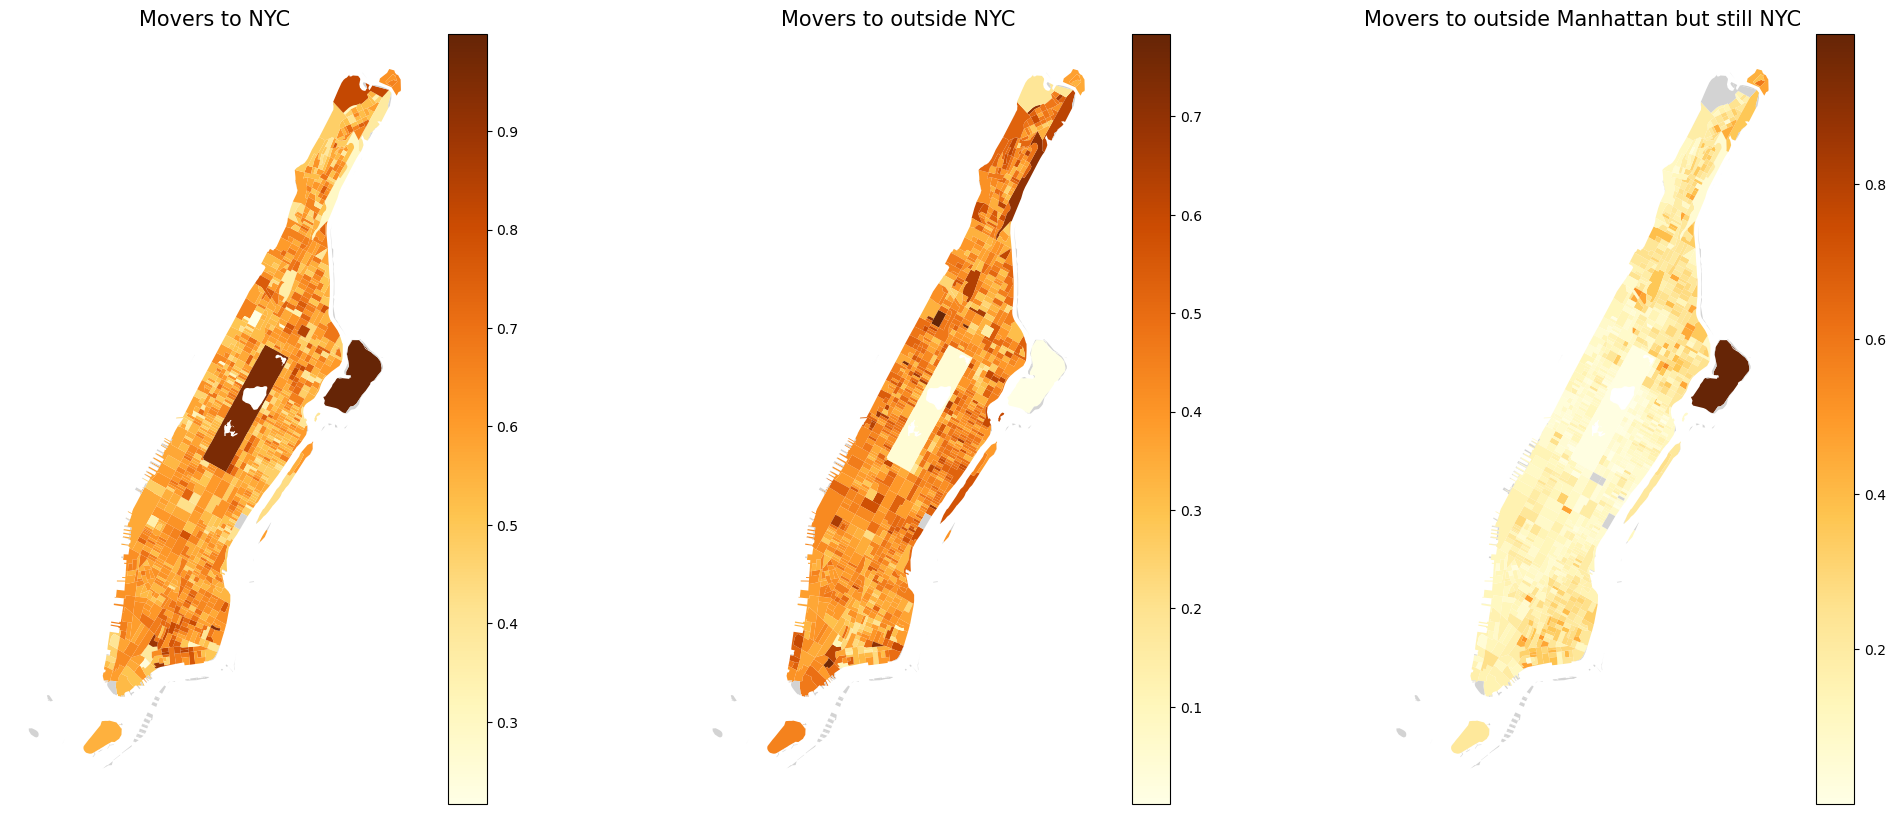

In [21]:
fig, Axes = plt.subplots(ncols=3, figsize=(25,10))
for ax_idx, column in enumerate(['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']):
    _ = Manhattan_CBGs.plot(column=f'{column} (fraction)', ax=Axes[ax_idx], legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'})
    _ = Axes[ax_idx].set_title(column, fontsize=15)
    _ = Axes[ax_idx].axis('off')

Note that the plot isn't quite illuminating at first---this is normal! We are seeing noise picked up much strongerly (so places like Central Park and Randall's Island have a high share, likely due to their very small number of people). As we are comparing three plots, we would also like to have them on the same scale. We can define `vmin` and `vmax` in our plot to standardize the bar, we can change the colorscale to something that allows for more nuances, and we can also omit CBGs with less than 5 movers.

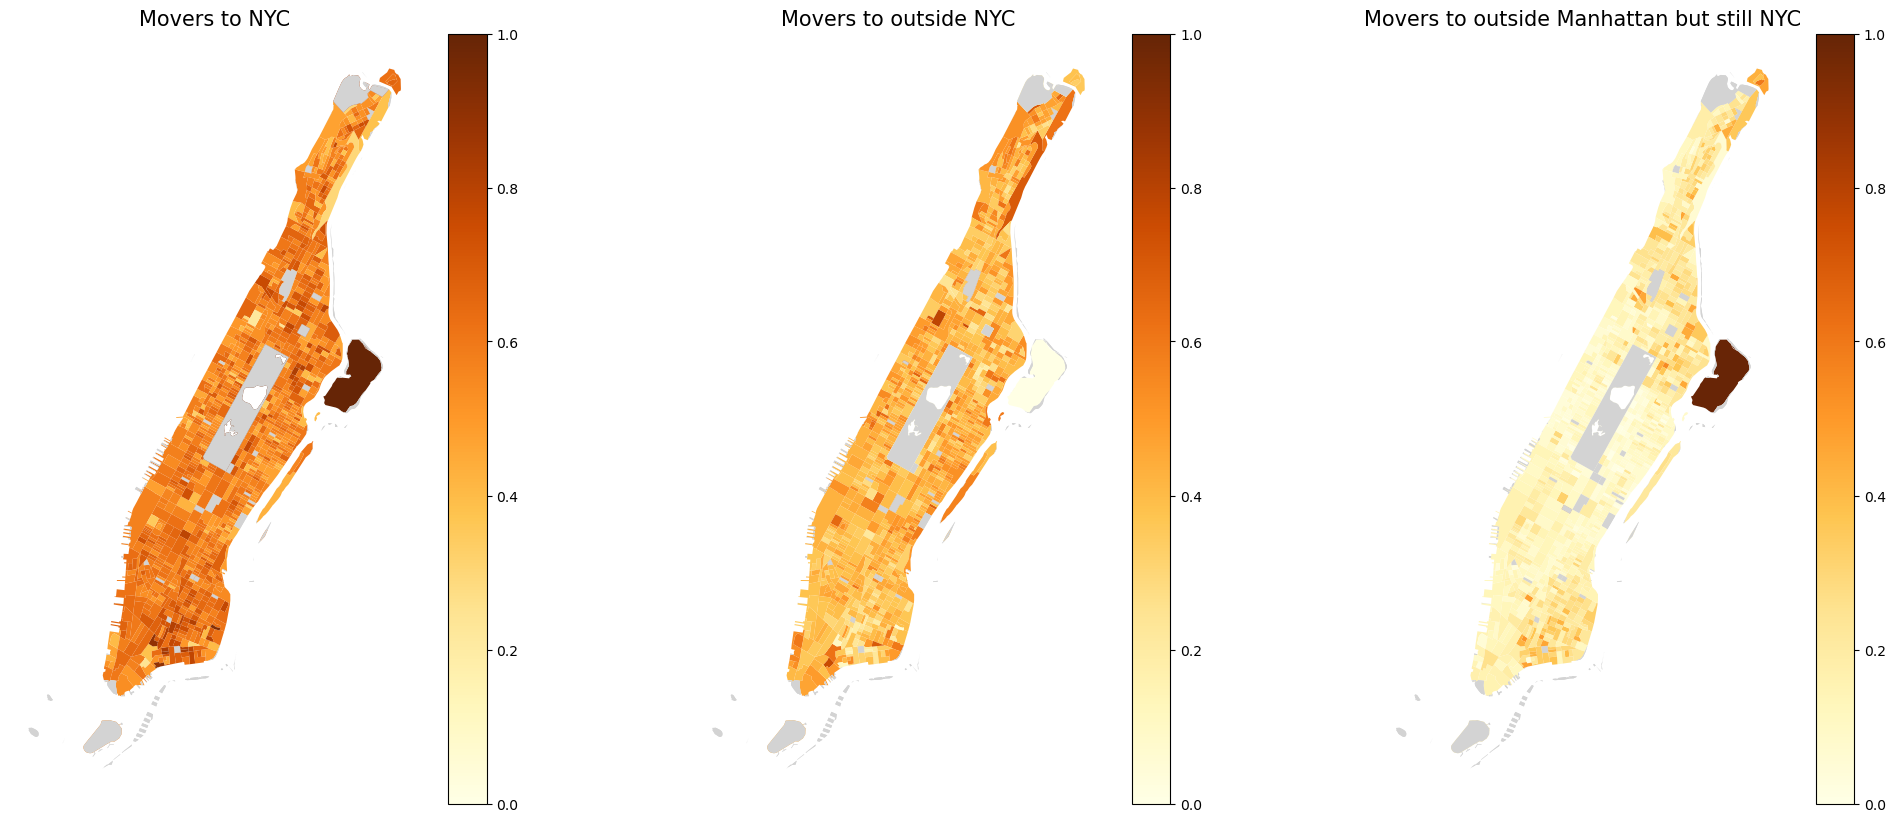

In [22]:
fig, Axes = plt.subplots(ncols=3, figsize=(25,10))
for ax_idx, column in enumerate(['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']):
    _ = Manhattan_CBGs.plot(column=f'{column} (fraction)', ax=Axes[ax_idx], legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'},
                            vmin=0, vmax=1., legend_kwds={'extend': 'neither'})#'max'})  # extend above vmax, crucial if you are setting vmax below 1! use 'neither', 'max', 'both', 'min'
    #Plot, in grey, the CBGs with less than 5 movers:
    _ = Manhattan_CBGs[Manhattan_CBGs['Total Movers'] <= 5].plot(color='lightgrey', ax=Axes[ax_idx], legend=False)
            
    _ = Axes[ax_idx].set_title(column, fontsize=15)
    _ = Axes[ax_idx].axis('off')

Ok! Now we see that the plots all have very different ranges---what stories can you tell about the geographical disparities you see? To tell another story, I would suggest that you restrict vmax to something where you can see color variation on the THIRD map---people who move outside of Manhattan but stay in New York City. What can be a socioeconomical reason for the results you are seeing?

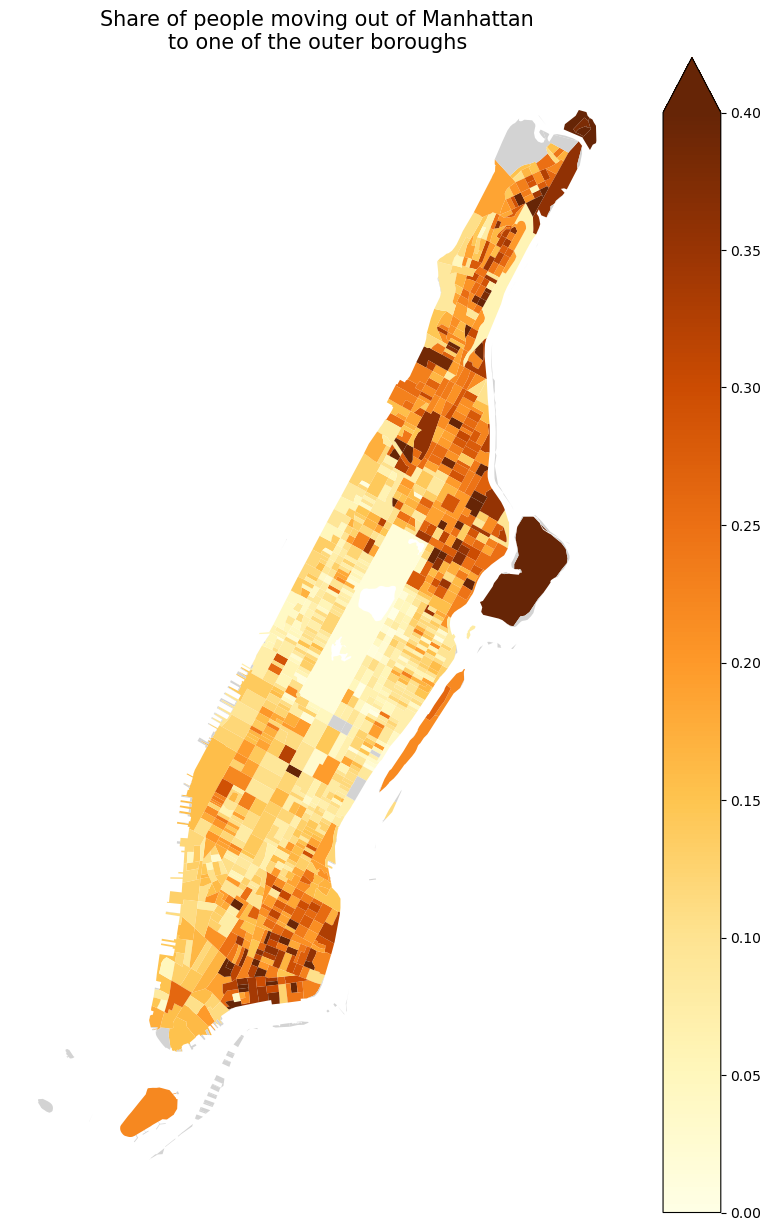

In [23]:
fig, ax = plt.subplots(figsize=(10,15))
_ = Manhattan_CBGs.plot(column='Movers to outside Manhattan but still NYC (fraction)', ax=ax, legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'},
                        vmin=0, vmax=.40, legend_kwds={'extend': 'max'})
_ = Manhattan_CBGs[Manhattan_CBGs['Total Movers'] <= 5].plot(color='lightgrey', ax=Axes[ax_idx], legend=False)
        
_ = ax.set_title('Share of people moving out of Manhattan\nto one of the outer boroughs', fontsize=15)
_ = ax.axis('off')

<b> One possible interpretation: </b> Neighborhoods where most movers leave Manhattan but stay in New York City are predominantly in the lower East Side, Chinatown, East Harlem, Washington Heights. Most of these are low-income neighborhoods in Manhattan, with predominantly non-white populations. One could make an argument about these people leaving the city center yet staying within reach from public transportation perhaps because they are tied to jobs. One could also look sepcifically about where these people are going---who's moving to Queens, to Bronx, to Brooklyn specifically? And this could potentially tell a story of gentrification of particular neighborhoods.

## 3. Mapping Out-Migration from Wildfires

Now let's look at migration in CBGs affected by the Camp fire in California---you can use this as an opportunity to learn about spatial joins! The wildfire [data,](https://www.fire.ca.gov/what-we-do/fire-resource-assessment-program/fire-perimeters) comes from the California department of Forestry and Fire Protection. I included the file in the `data` directory:

In [25]:
wildfire_perimeter = gpd.read_file('../data/wildfire_polygons.gdb', layer='firep24_1') #Read a geodatabase file by reading the folder!

/Users/gsagostini/opt/anaconda3/envs/neatnet-debug/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Check how the dataframe looks like:

In [26]:
wildfire_perimeter.head()

,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,C_METHOD,CAUSE,COMPLEX_NAME,COMPLEX_ID,OBJECTIVE,GIS_ACRES,COMMENTS,FIRE_NUM,Shape_Length,Shape_Area,geometry
0,2025.0,CA,CDF,LDF,PALISADES,00000738,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},2025-01-07 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,None,None,1.0,23448.882812,None,None,116028.197349,9.489426e+07,"MULTIPOLYGON (((136696.228 -441776.379, 136683..."
1,2025.0,CA,CDF,LAC,EATON,00009087,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},2025-01-08 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,None,None,1.0,14056.260742,None,None,86677.545056,5.688367e+07,"MULTIPOLYGON (((175062.878 -425909.927, 175066..."
2,2025.0,CA,CDF,ANF,HUGHES,00250270,{994072D2-E154-434A-BB95-6F6C94C40829},2025-01-22 00:00:00+00:00,2025-01-28 00:00:00+00:00,7.0,14,None,None,1.0,10396.798828,None,None,79554.126153,4.207435e+07,"MULTIPOLYGON (((132177.534 -380697.661, 132181..."
3,2025.0,CA,CCO,VNC,KENNETH,00003155,{842FB37B-7AC8-4700-BB9C-028BF753D149},2025-01-09 00:00:00+00:00,2025-02-04 00:00:00+00:00,2.0,14,None,None,1.0,998.737793,from OES Intel 24,None,12891.056545,4.041748e+06,"MULTIPOLYGON (((121967.885 -426575.817, 121970..."
4,2025.0,CA,CDF,LDF,HURST,00003294,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},2025-01-07 00:00:00+00:00,2025-01-09 00:00:00+00:00,7.0,14,None,None,1.0,831.385498,None,None,13274.108148,3.364498e+06,"MULTIPOLYGON (((140774.966 -408332.494, 140784..."


Let's select the rows corresponding to CAMP fire. note that simply selecting by name may be insufficient---you might need to use the YEAR or other data to select the correct row:

In [27]:
camp_fire_gdf = wildfire_perimeter[(wildfire_perimeter.FIRE_NAME=='CAMP')&(wildfire_perimeter.YEAR_==2018)&(wildfire_perimeter.ALARM_DATE.dt.month==11)]
display(camp_fire_gdf)
#HINT: use & for "and" conditions, | for "or" conditions. You may need to know the month and year of camp fire. Do one query, print all rows, and refine it until you get the right one.
# Your final query should return exactly one row.

,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,C_METHOD,CAUSE,COMPLEX_NAME,COMPLEX_ID,OBJECTIVE,GIS_ACRES,COMMENTS,FIRE_NUM,Shape_Length,Shape_Area,geometry
2356,2018.0,CA,CDF,BTU,CAMP,00016737,{75E64DB8-9B75-4A68-BEDD-67CC62658E38},2018-11-08 00:00:00+00:00,2018-11-26 00:00:00+00:00,1.0,11,None,None,1.0,153335.5625,None,None,311935.278756,6.205270e+08,"MULTIPOLYGON (((-141808.575 178057.983, -14181..."


Can you plot this perimeter?

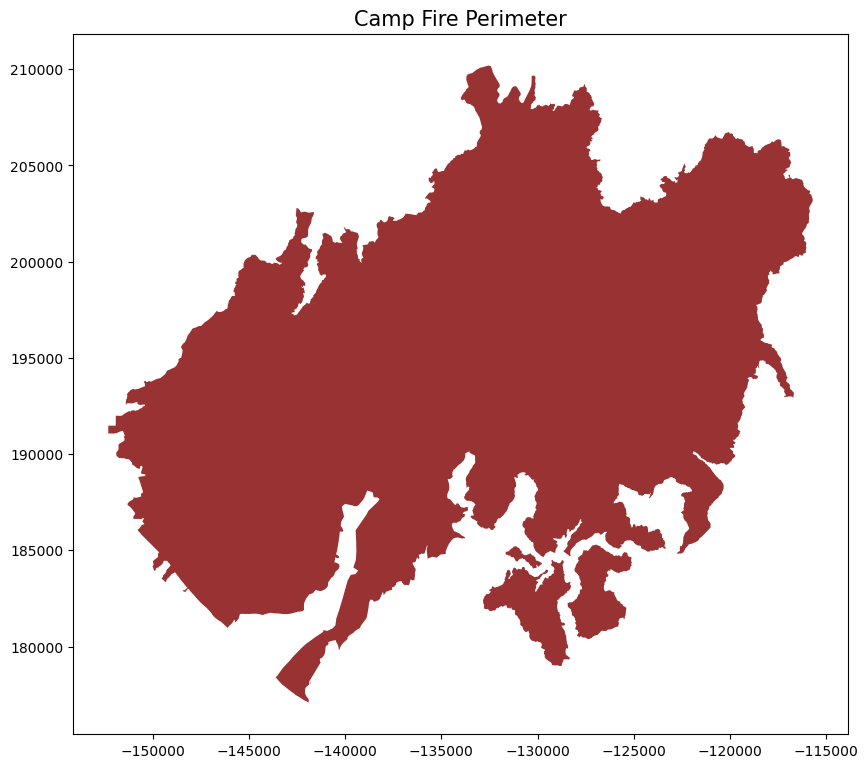

In [28]:
#Some interesting arguments of GeoDataFrame.plot include:
# - color to define a single color for all geometries
# - edgecolor to define the color of the geometry borders
# - linewidth to define the width of the geometry borders
# - alpha to define transparency (0=fully transparent, 1=fully opaque)
# You can also call .boundary on a GeoSeries or GeoDataFrame to get just the boundaries of the geometries, which you can then plot.

fig, ax = plt.subplots(figsize=(10,10))
_ = camp_fire_gdf.plot(color='maroon', alpha=0.8, ax=ax)
_ = ax.set_title('Camp Fire Perimeter', fontsize=15)

### Geographic projections:

<b> This might be the most important learning goal of the workshop: </b> Spatial data has <i>projections</i>. The Eart is round, and representing it in a two-dimensional way requires that we define a coordinate reference system (crs). For example, you may have learned about Mercator, Peters, and other cartographical projections. You can query your GeoDataFrame crs by using the `crs` attribute:

In [29]:
wildfire_perimeter.crs

<Projected CRS: EPSG:3310>
Name: NAD83 / California Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - California.
- bounds: (-124.45, 32.53, -114.12, 42.01)
Coordinate Operation:
- name: California Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Importantly, look at the dimensions: this is a metric projection in meters, so any length or area operations will give results in meters. Now look at the crs of the California CBG polygons:

In [30]:
CA_CBGs.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

This is a <b> geodetic </b> projection, meaning that it simply flattens the Earth's sphere respecting latitude and longitude---it is highly interpretable (you can just look at lat long and query, for example), but it will not work for any geographic operations (e.g. computing lengths, or areas, or joining things because this requires computing distances). For example, look at the warnings you receive:

In [31]:
CA_CBGs.iloc[:10].area

/var/folders/f2/v4vrkjfn5q7_6pt8hc7y52wr0000gn/T/ipykernel_51270/4103404054.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  CA_CBGs.iloc[:10].area


0    0.000158
1    0.003605
2    0.012574
3    0.000046
4    0.000103
5    0.000337
6    0.000040
7    0.001715
8    0.000872
9    0.000286
dtype: float64

It's good practice to always keep a variable with your crs around. For this case, let's project the CA_CBGs file to the same crs as the wildfire polygons (which is in meters):

In [32]:
CA_CBGs_projected = CA_CBGs.to_crs(wildfire_perimeter.crs)

Try computing the area now---waht are these units?

In [33]:
CA_CBGs_projected.iloc[:10].area

0    1.570669e+06
1    3.581016e+07
2    1.250224e+08
3    4.600325e+05
4    1.025436e+06
5    3.348551e+06
6    3.963528e+05
7    1.697455e+07
8    8.629344e+06
9    2.831433e+06
dtype: float64

### Joining Spatial Data

We have a GeoDataFrame of a wildfire polygon and a GeoDataFrame of Census Block Groups. Let's ask ourselves the question of which CBGs are affected by the fire. First, let's visualize the CBGs and the fire polygon:

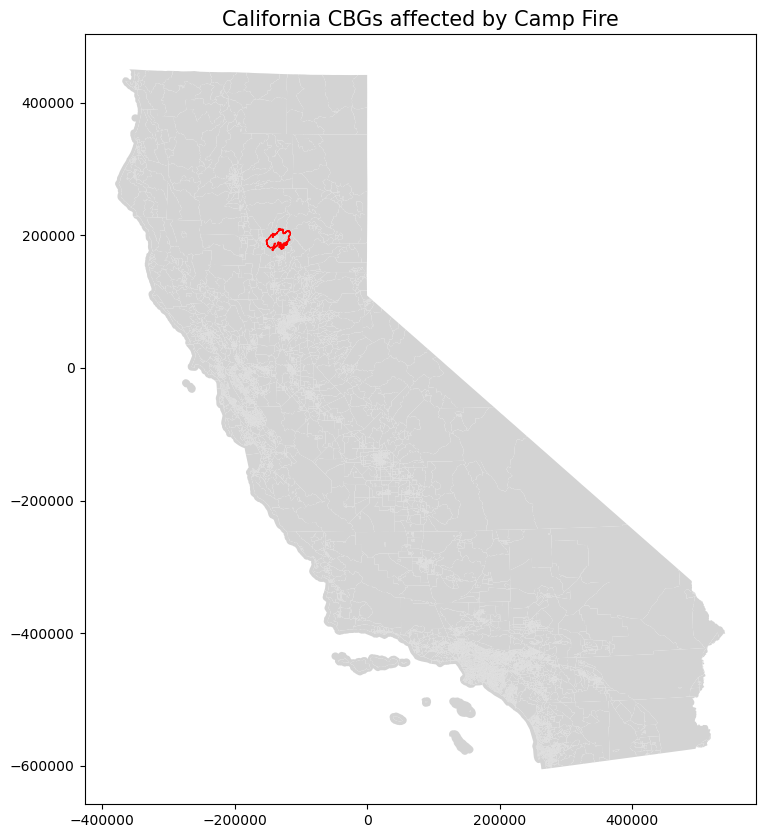

In [34]:
#Plot both the fire perimeter and the CBGs in the same axis. If they are on the same projection, they should line up.
fig, ax = plt.subplots(figsize=(10,10))
_ = CA_CBGs_projected.plot(ax=ax, color='lightgrey', zorder=-1)
_ = camp_fire_gdf.boundary.plot(ax=ax, color='red', linewidth=1)
_ = ax.set_title('California CBGs affected by Camp Fire', fontsize=15)


You can zoom into the fire perimeter either by seeting ax limits (use `ax.set_xlim` and `ax.set_ylim`) or by using `cx` on a GeoDataFrame. The latter is more useful if you want to avoid plotting some CBGs, but it will show things outside the polygon if they at some point intersect the polygon:

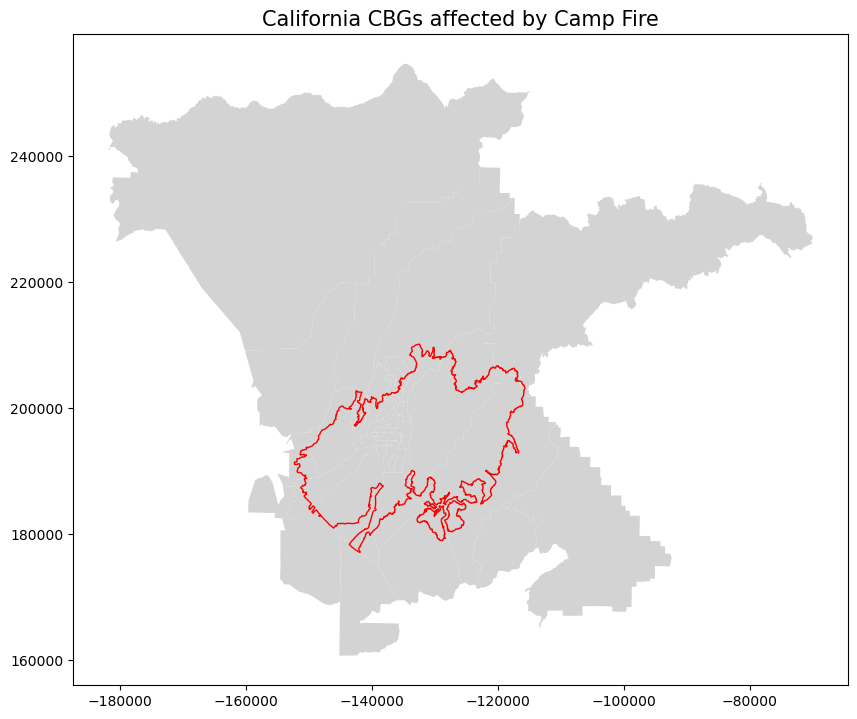

In [35]:
total_bounds = camp_fire_gdf.total_bounds  # returns (minx, miny, maxx, maxy)
cropped_CBGs = CA_CBGs_projected.cx[total_bounds[0]:total_bounds[2], total_bounds[1]:total_bounds[3]] #this is a square-like box cropping!

#Now plot the cropped CBGs with the same code you wrote above:
fig, ax = plt.subplots(figsize=(10,10))
_ = cropped_CBGs.plot(ax=ax, color='lightgrey', zorder=-1)
_ = camp_fire_gdf.boundary.plot(ax=ax, color='red', linewidth=1)
_ = ax.set_title('California CBGs affected by Camp Fire', fontsize=15)

To actually selec the CBGs intersecting the polygon, we can use `overlay`

In [38]:
CA_CBGs_projected.overlay?

Signature:
CA_CBGs_projected.overlay(
    right: 'GeoDataFrame',
    how: "Literal['intersection', 'union', 'identity', 'symmetric_difference', 'difference']" = 'intersection',
    keep_geom_type: 'bool | None' = None,
    make_valid: 'bool' = True,
)
Docstring:
Perform spatial overlay between GeoDataFrames.

Currently only supports data GeoDataFrames with uniform geometry types,
i.e. containing only (Multi)Polygons, or only (Multi)Points, or a
combination of (Multi)LineString and LinearRing shapes.
Implements several methods that are all effectively subsets of the union.

See the User Guide page :doc:`../../user_guide/set_operations` for details.

Parameters
----------
right : GeoDataFrame
how : string
    Method of spatial overlay: 'intersection', 'union',
    'identity', 'symmetric_difference' or 'difference'.
keep_geom_type : bool
    If True, return only geometries of the same geometry type the GeoDataFrame
    has, if False, return all resulting geometries. Default is None,
    w

Select the CBGs. Use the `how='intersection'` parameter:

In [39]:
CA_CBGs_in_Camp = CA_CBGs_projected.overlay(camp_fire_gdf, how='intersection')

Plot the `CA_CBGs_in_Camp` dataset:

<Axes: >

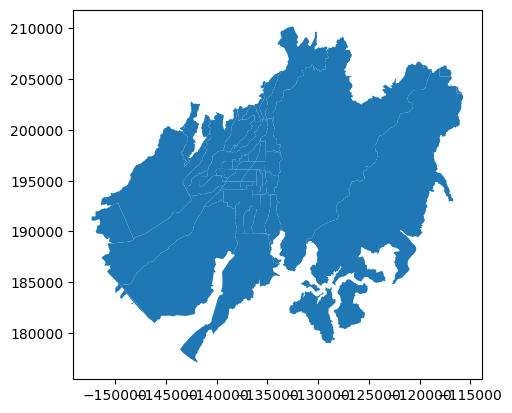

In [40]:
CA_CBGs_in_Camp.plot()

One caveat: this cropped some CBGs, showing all those partially affected by the fire. One important consideration is the fraction of each CBG affected. To understand that, you will need to compute area fractions.

In [41]:
#Compute the area of each CBG in the cropped dataset:
area_in_camp = CA_CBGs_in_Camp.set_index('GEOID10').area #setting the index to GEOID10 makes it easier to look up areas by GEOID later

#Compute the area of each CBG in California---remember to read about projections above!:
area_in_CA = CA_CBGs_projected.set_index('GEOID10').area

#Compute the area fraction of each CBG affected by the fire:
# You might want to fill nans with zeroes.
area_fraction_in_camp = (area_in_camp / area_in_CA).fillna(0)

Merge the `area_fraction_in_camp` series on the `GEOID10` column back into the `CA_CBGs_projected` geodataframe, then plot. You can set vmin and vmax to 0 and 1.

<Axes: >

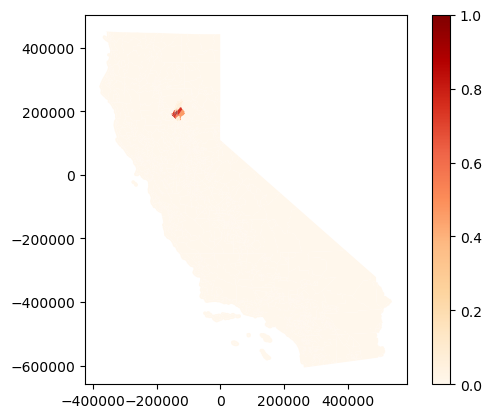

In [42]:
#Merge the area fractions back into the original CA_CBGs_projected geodataframe:
CA_CBGs_projected = CA_CBGs_projected.merge(area_fraction_in_camp.rename('Fraction in Camp Fire'), left_on='GEOID10', right_index=True, how='left')
CA_CBGs_projected.plot('Fraction in Camp Fire', vmin=0, vmax=1, legend=True, cmap='OrRd', missing_kwds={'color':'lightgrey', 'label':'No data'})

Try to also zoom:

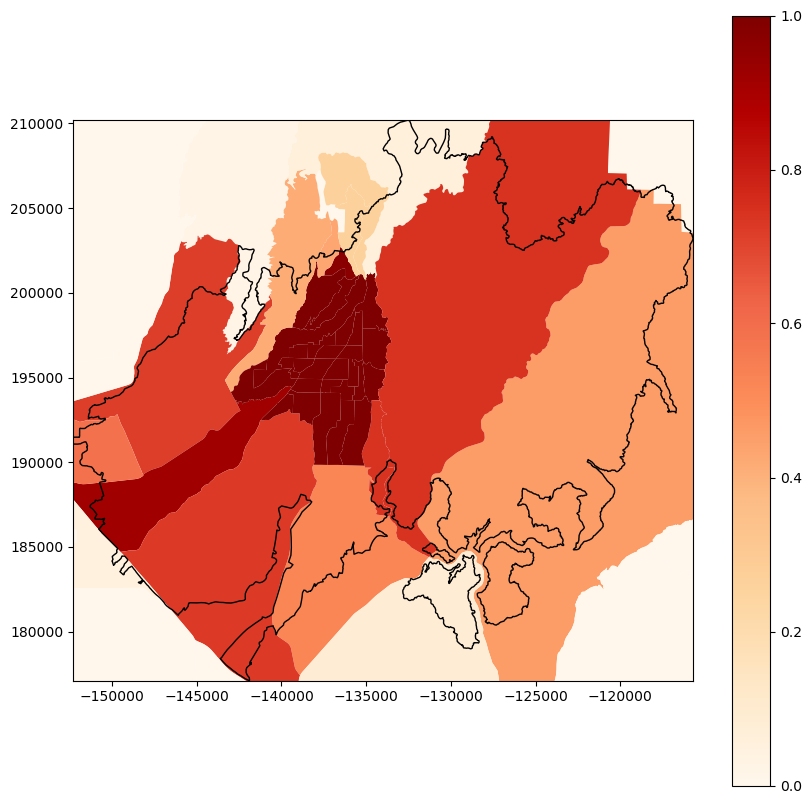

In [43]:
fig, ax = plt.subplots(figsize=(10,10))
CA_CBGs_projected.plot('Fraction in Camp Fire', ax = ax, vmin=0, vmax=1, legend=True, cmap='OrRd', missing_kwds={'color':'lightgrey', 'label':'No data'})
camp_fire_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
_ = ax.set_xlim(total_bounds[0], total_bounds[2])
_ = ax.set_ylim(total_bounds[1], total_bounds[3])

For some analysis, you might want to set a threshold and only consider CBGs with more than $\alpha \%$ of their area inside a polygon, for example.

### Visualizing out-migration

Now let's visualize out-migration from MIGRATE. Let's first select flows out of all CBGs within $25km$ from the fire perimeter:

<Axes: >

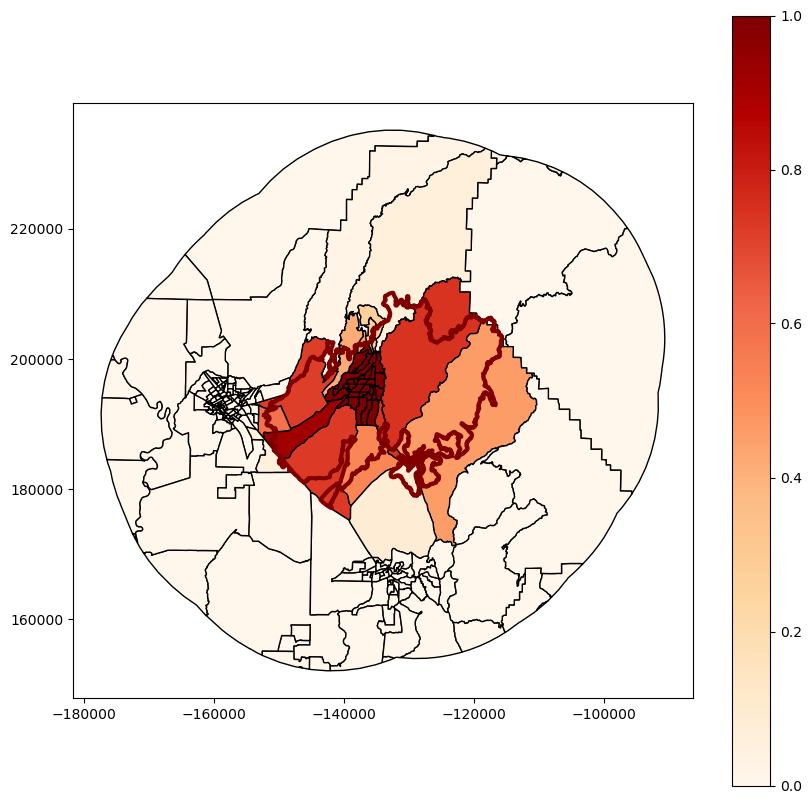

In [44]:
#To find CBGs within a certain distance from the fire perimeter, we can use the .buffer() method to create a buffer around the fire perimeter, then use overlay
buffer_distance = 25*1000 #25km in meters (this is the unit of the projection!)
buffered_polygon = camp_fire_gdf.geometry.buffer(buffer_distance) #This creates as GeoSeries! You will need to create a GeoDataFrame if you want to use overlay.
buffered_polygon_gdf = gpd.GeoDataFrame(geometry=buffered_polygon)

#Use overlay:
CA_CBGs_of_interest = CA_CBGs_projected.overlay(buffered_polygon_gdf, how='intersection')

#Plot to visaulize (along with fire polygon)---I recommend setting linewidth=1 and edgecolor='black' for the CBGs gdf to see CBG boundaries:
fig, ax = plt.subplots(figsize=(10,10))
CA_CBGs_of_interest.plot('Fraction in Camp Fire', ax = ax, vmin=0, vmax=1, linewidth=1, edgecolor='k', legend=True, cmap='OrRd', missing_kwds={'color':'lightgrey', 'label':'No data'})
camp_fire_gdf.boundary.plot(ax=ax, color='maroon', linewidth=3)

Now select from MIGRATE_df all outflows from those CBGs---the same thing you did for New York. Note that now you might want to first query what CBGs have GEOIDs in your selected gdf, and then query for rows of `MIGRATE_df` with those GEOIDs in `Origin`:

In [45]:
MIGRATE_data['Origin'] = MIGRATE_data['Origin'].astype(str).str.zfill(12) #this might already be done!
MIGRATE_data['Destination'] = MIGRATE_data['Destination'].astype(str).str.zfill(12) #this might already be done!

#Get a list of GEOIDs of CBGs of interest using .values on the geodataframe above and query MIGRATE_data for outflows from those CBGs-:
GEOIDs_to_query = CA_CBGs_of_interest['GEOID10'].values
selected_outflows = MIGRATE_data.loc[MIGRATE_data['Origin'].isin(GEOIDs_to_query)]

#Remember that we would like to aggregate by origin:
total_outflows = selected_outflows.groupby('Origin')['Flow'].sum()

#Also, get stayers and the total movers, as you did for Manhattan above:
flows_to_the_same_CBG = selected_outflows.loc[selected_outflows['Origin']==selected_outflows['Destination']].groupby('Origin')['Flow'].sum()
total_movers = total_outflows - flows_to_the_same_CBG

Visualize the fraction of flows who moved out of the CBG (this is the out-migration rate, as the total `flow` in our terminology is people who moved out + people who stayed)

<Axes: >

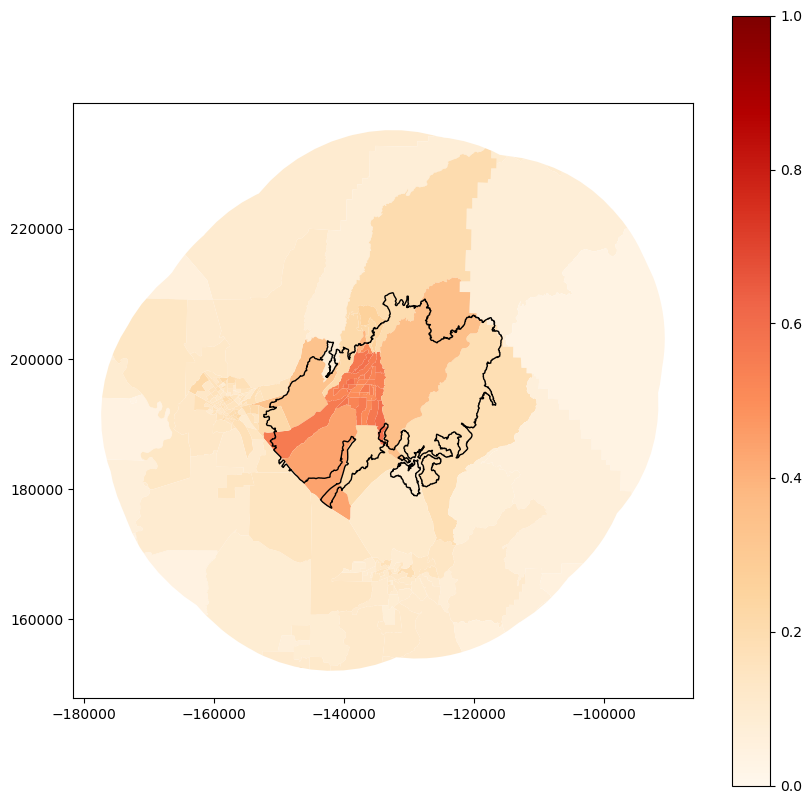

In [46]:
#Compute the outmigration rate:
outmigration_rate = total_movers / total_outflows

#Merge into the GeoDataFrame:
CA_CBGs_of_interest = CA_CBGs_of_interest.merge(outmigration_rate.rename('out-migration_rate'), left_on='GEOID10', right_index=True, how='left')

#Plot:
fig, ax = plt.subplots(figsize=(10,10))
CA_CBGs_of_interest.plot('out-migration_rate', ax = ax, vmin=0, vmax=1, legend=True, cmap='OrRd', missing_kwds={'color':'lightgrey', 'label':'No population'})
camp_fire_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

## 4. More Fun Stuff if you have time!

If you got here, it means you are a pro at plotting and visualizing spatial data already! Here are some interesting analyses you could play with:

- Can you figure out destinations of folks moving from CBGs affected by Camp Fire? How many people (in share of movers) end up in CBGs inside the fire perimeter? How many people end up in an affected county---you might want to look up counties---or an adjacent county but outside the fire perimeter? How many people leave California altogether?
- What about cross-area flows. You have access to all flows departing from New York and California. How many people are moving from each NYC borough to San Francisco---this is basically a county-to-county flow, which we now can verify yearly but beforehand we only had access to at a 5-year aggregate. How many people from each NYC CBG are doing that? 